In [1]:
import pandas as pd
import numpy as np
import re

pd.options.display.max_columns = None

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


### `Question-1A:`

You are given a dataset about the cars' price and miles driven of different cars throughout the different years. The link of the dataset: https://tinyurl.com/2r24n45l. Your tasks are
- make a pivot table of the brands (the required brands are given below) from the "Year" 2018 to the year 2022 in which the "Price" is shown as average values and "Miles" are in median values. In this pivote table, every row represents a particular brand and each column represents either average "Price" of a partucular year or median values of "Miles" of a particular year.
- At the end plot a kde chart for the "Price" and "Miles" by using your pivot table.

There are some challenges to solve this task:
- There is no column that is represented to the brand name of the car. You have to find out on your own.
- Some values of "Years" column are misleading. You have to reset this column too that every value should tell a valid meaning.

<Axes: ylabel='Density'>

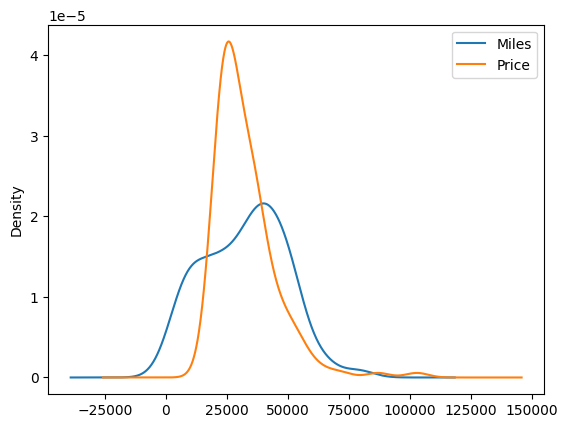

In [2]:
# code here

car = pd.read_csv('data/22_data/carvana - carvana.csv')
car["brand"] = car["Name"].str.split().str.get(0)
car["Year"] = car["Year"].astype('str')
def fun(row):
    if len(row)>4:
        return row[0:4]
    else:
        return row

car["Year"] = car["Year"].apply(fun)
y = car[car["Year"].isin(["2018", "2019", "2020", '2021', "2022"])]

pi = y.pivot_table(index="brand", columns="Year", values=["Price", "Miles"] , aggfunc={"Price":'mean', "Miles":'median'})
pi.stack().plot(kind='kde')

### `Question-2:`

You are given a dataset of **Daily Power Generation in India** of regional wise of all Power Stations. Link of the dataset: https://tinyurl.com/2nq6kugt

Task
- In this dataset, there are many columns. Two of them are `Actual(MU)` and `Excess(+) / Shortfall (-)`. `Actual(MU)` represents the actual power generation. `Excess(+) / Shortfall (-)` tells is that generated power is excess or shortfall for that particular day of a power station. You have to find out what should be the actual power generation required for that day by the power stations that there would not be any excess or shorfall power. For the result, make a new column.
- Find out the month of the day and store it as a new column.
- Find out top 10 frequently appeared power stations in this dataframe.
- Next create a pivot table of which every row represents a power station and every column represents a month in a order. Like January, February, March...
- It is hard to get inside if you look through the only pivot table. So plot the pivot table.

<Axes: xlabel='Month', ylabel='Power Station'>

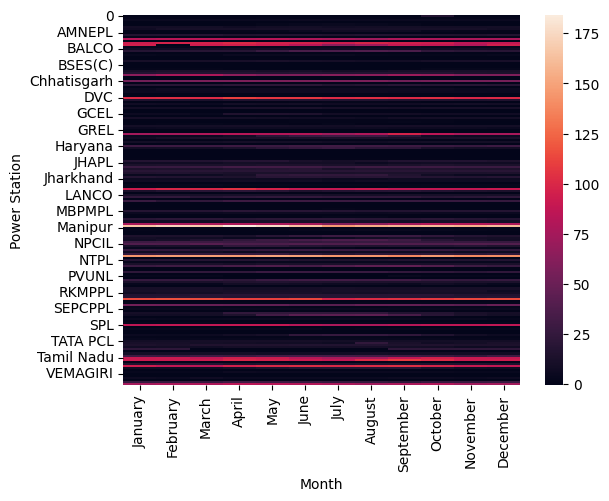

In [34]:
# code here
import seaborn as sns
p = pd.read_csv('data/22_data/PowerGeneration - PowerGeneration.csv')
p["Required_Power"] = p["Actual(MU)"] - p["Excess(+) / Shortfall (-)"]
p["Dates"] = pd.to_datetime(p["Dates"])
p["Month"] = p["Dates"].dt.month_name()
p["Day"] = p["Dates"].dt.day_name()
p["Power Station"].value_counts().sort_values(ascending=False).head(10)
d = pd.pivot_table(data=p, index="Power Station", columns="Month", values="Required_Power", fill_value=0)\
    [["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]]
sns.heatmap(data=d)

### `Q-4` You are given a file `question-answer.csv`. Your task is to make a dataframe from it with two columns - `question` and `answers`.

* Questions in the file start from `Q<number>`; E.g.  `Q1` denotes question no. `1`
* Answers starts from `Ans<number>`; Eg. `Ans1` denotes answer of question no `1`
* MAke sure you look at columns name carefully

CSV File - "https://drive.google.com/file/d/10rmV3XrVtzpDTtYZF3UtCdcU0ajBJjGY/view?usp=share_link"

In [ ]:
# code here
# Method_1

q = pd.read_csv("data/22_data/question-answer.csv")
ques = q[q["2"].str.startswith('Q')].rename(columns={"2":"questions"}).reset_index()
ans = q[q["2"].str.startswith('A')].rename(columns={"2":"answer"}).reset_index()
pd.concat([ques, ans], axis=1).drop(columns=["index", "Unnamed: 0"])


,questions,answer
0,Q1-What is Data Science?,"Ans1-Data Science combines statistics, maths, ..."
1,Q2-2. How is logistic regression done?,Ans2-Logistic regression measures the relation...
2,Q3-How do you build a random forest model?,Ans3-A random forest is built up of a number o...
3,Q4-How can you avoid overfitting your model?,Ans4-Overfitting refers to a model that is onl...
4,Q5-You are given a data set consisting of vari...,Ans5-The following are ways to handle missing ...
5,Q6-What is bag of words? How we can use it for...,Ans6-Bag of Words is a representation of text ...
6,Q7-How can we use machine learning for text cl...,Ans7-Machine learning classification algorithm...
7,Q8-What is a time series?,Ans8-A time series is a set of observations or...
8,Q9-How is time series different from the usual...,Ans9-The principle behind causal forecasting i...
9,Q10-What are the different types of joins? Wha...,Ans10-(INNER) JOIN: Returns records that have ...


In [87]:
ques = q[q["2"].str.startswith('Q')].rename(columns={"2":"question"}).reset_index().drop(columns=["index", "Unnamed: 0"])
ans = q[q["2"].str.startswith('A')].rename(columns={"2":"answer"}).reset_index().drop(columns=["index", "Unnamed: 0"])
ques[["No", "question"]] = ques["question"].str.split("-", n=1, expand=True)
ans[["No", "answer"]] = ans["answer"].str.split("-", n=1, expand=True)
ques["No"]=ques["No"].str.replace("Q", "")
ans["No"]=ans["No"].str.replace("Ans", "")
df = pd.merge(ques, ans, on='No', how="inner")[["No", "question", "answer"]]

### `Q-5`: Print Question and answer of those questions which does not contains any question mark (`?`).


In [100]:
# code here

df[~df["question"].str.endswith("?")]

,No,question,answer
